In [10]:
import random
random.seed(42)
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
#import bcolz
import pandas
import allel; print('scikit-allel', allel.__version__)
%reload_ext memory_profiler
from itertools import compress
from collections import *
from functools import reduce
import pandas as pd

scikit-allel 1.3.5


In [11]:
def plot_pca_coords(coords, model, pc1, pc2, ax, sample_population):
    sns.despine(ax=ax, offset=5)
    x = coords[:, pc1]
    y = coords[:, pc2]
    for pop in populations:
        flt = (sample_population == pop)
        ax.plot(x[flt], y[flt], marker='o', linestyle=' ', color=pop_colours[pop], 
                label=pop, markersize=6, mec='k', mew=.5)
    ax.set_xlabel('PC%s (%.1f%%)' % (pc1+1, model.explained_variance_ratio_[pc1]*100))
    ax.set_ylabel('PC%s (%.1f%%)' % (pc2+1, model.explained_variance_ratio_[pc2]*100))
    

def fig_pca(coords, model, title, sample_population=None):
    if sample_population is None:
        sample_population = df_samples.population.values
    # plot coords for PCs 1 vs 2, 3 vs 4
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 2, 1)
    plot_pca_coords(coords, model, 0, 1, ax, sample_population)
    ax = fig.add_subplot(1, 2, 2)
    plot_pca_coords(coords, model, 2, 3, ax, sample_population)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()

In [12]:
def window_GT(callset, window, mode="SNP", start=0, step=None):
    '''
    split the genotype into windows based on the num of SNPs or physical chromosome position.
    default start from 0
    '''
    genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
    if mode == "SNP":
        while start < len(genotype) - window:
            start += window 
            gt_subset = genotype[start : start + window]
            yield gt_subset 
        else:
            gt_subset = genotype[start : ] #final should be 31497110
            yield gt_subset
            
    elif mode == "BP":
        start = 0
        end = start + 100
        med = (start + end) / 2
        pos_dict = defaultdict(list)
        for i in pos:
            #filter(lambda x: x not in subset_of_A, A)
            if end > i > start:
                pos_dict[med].append(i)
                #print("process 1 " + str(i))
            else:
                while i >= end:
                    start += 100
                    end  += 100
                    med = (start + end) / 2
            pos_dict[med].append(i) if i not in pos_dict[med] else pos_dict[med]
            
        # temp pos of pos array
        temp_pos = 0 
        for k,v in pos_dict.items():
            temp_pos_start = temp_pos
            temp_pos_end = temp_pos_start + len(v)
            temp_pos = len(v)
            gt_subset_BP = genotype[temp_pos_start : temp_pos_end]
            yield gt_subset_BP
            
    else:
        print("please specify the mode of sliding window: mode = ['SNP', 'BP']")

# # do window-based PCA
# for i in window_GT(g, 100):
#     flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)#biallelic
#     gf = i.compress(flt, axis=0)
#     gn = gf.to_n_alt() 

In [146]:
# read vcf file and make genotype matrix
callset = allel.read_vcf("/Users/evolutioneco/Project/3.SV/localPCA/singlePop/Aripo/Aripo.LG4.vcf")
# population 
df_samples = pandas.read_csv('/Users/evolutioneco/Project/3.SV/localPCA/singlePop/Aripo/Aripo.samplex_in_vcf.txt', delimiter='\t')
df_samples.head()
sample_size = 40
populations = df_samples.population.unique()
pop_colours = {
    'ArH': 'red',
    'ArL': 'blue'
}
# fisrt eigenvector stored in a dictionary {med_pos: first_eigen_vector}
##### maybe matrix???? 
#coord_dict = defaultdict(list)

#coord_matrix = np.zeros((5018, 42))
# output matrix should look like this  
# sample  1st_eigenvector  2nd_eigenvector  3rd_eigenvector  4th_eigenvector   mid  
# indv1      1.1               1.2              1.3              1.4          1932
# indv2      1.1               1.2              1.3              1.4          1932
# indv3      1.1               1.2              1.3              1.4          1932
# indv4      1.1               1.2              1.3              1.4          1932
# indv5      1.1               1.2              1.3              1.4          1932
#  ...
#
# indv40    1.2               1.5              1.4              1.7          1932


count = 0 
start = 0
window = 100
end = start + window # 100 SNPs
rows = 40
cols = 10 
coord_matrix = callset['samples']
# samples 
samples = callset['samples'] # array
sample_size = len(samples) 
#
start_df = pd.DataFrame()

#write into matrix
for subset_gt in window_GT(callset, window, "SNP", start=0, step=None):
    count += 1
    subset_gt_start = start
    subset_gt_end = subset_gt_start + len(subset_gt) 
    ac = subset_gt.count_alleles()[:] 
    # SNP filtering and only keep biallelic, remove singleton SNPs
    flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1) 
    gf = subset_gt.compress(flt, axis=0) # actual SNP filterings
    gn = gf.to_n_alt() #convert genotype data into...
    # actual postion 
    chrom_pos = list(compress(callset["variants/POS"][subset_gt_start:subset_gt_end], flt)) # actual chromosome postion
    chrom_pos_mean = np.zeros(sample_size) + (sum(chrom_pos)//len(chrom_pos)) #med of chromosome postion
    coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')
    # coords1.shape (40, 10)
    fisrt_eigenvector = coords1[:, 0] # pc1 coords1.components_[:,1]
    second_eigenvector = coords1[:, 1] # pc2 coords1.components_[:,1]
    tmp_array = np.column_stack((samples, chrom_pos_mean, coords1))
    tmp_df = pd.DataFrame(tmp_array)
    start_df = start_df.append(tmp_df)   
    # new start
    start += window
    
# sample  1st_eigenvector  2nd_eigenvector  3rd_eigenvector  4th_eigenvector   mid  
# indv1      1.1               1.2              1.3              1.4          1932
# indv2      1.1               1.2              1.3              1.4          1932
# indv3      1.1               1.2              1.3              1.4          1932
# indv4      1.1               1.2              1.3              1.4          1932
# indv5      1.1               1.2              1.3              1.4          1932
#  ...
#
# indv40    1.2               1.5              1.4              1.7          1932

    
# # count alleles 
# ac = g.count_alleles()[:]
# # SNP filtering and only keep biallelic 
# flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
# gf = g.compress(flt, axis=0)
# gn = gf.to_n_alt()
# multiallelic
# np.count_nonzero(ac.max_allele() > 1)
# biallelic singletons
# np.count_nonzero((ac.max_allele() == 1) & ac.is_singleton(1))

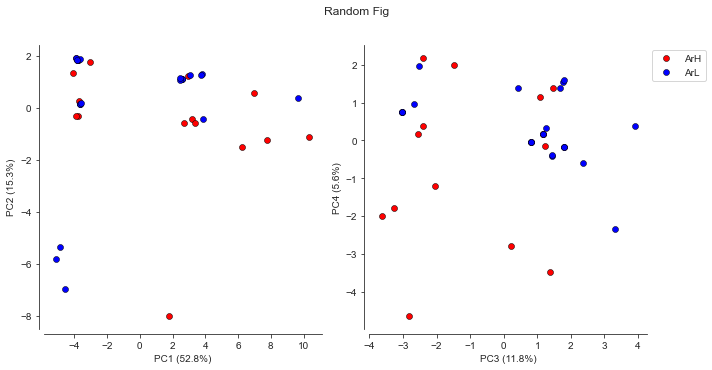

In [147]:
fig_pca(coords1, model1, "Random Fig")

In [148]:
start_df

,0,1,2,3,4,5,6,7,8,9,10,11
0,ARH-F2,5995.0,-7.505337,-1.105012,-8.526198,-8.577261,0.26018,-0.424442,3.583876,0.420183,0.541409,-6.541924
1,ARH-F24,5995.0,6.736376,-4.173593,-0.838114,1.604409,0.736172,-0.998907,-0.575807,1.656119,1.340969,-3.890832
2,ARH-M1,5995.0,-5.211952,-5.479156,2.045217,3.886718,-4.934603,8.85695,2.69498,4.213513,-2.072576,-0.288562
3,ARH-M16,5995.0,-16.743353,3.297144,-3.813453,1.912191,13.579986,1.80617,-7.645436,-4.124647,-2.112419,0.181048
4,ARL-M15,5995.0,5.610686,0.526781,-0.931022,0.409699,-0.47602,-3.104285,2.445184,-2.721512,-2.298646,2.373887
...,...,...,...,...,...,...,...,...,...,...,...,...
35,ArL-M12,31491747.0,-4.870942,-5.324995,3.905007,0.384724,-0.663954,1.326392,-0.908921,0.139438,-0.365178,0.00246
36,ArL-M16,31491747.0,-3.651898,0.165907,-3.032287,0.742313,-0.831493,0.130103,-0.464692,0.075991,-0.455517,-0.046879
37,ArL-M19,31491747.0,-3.651898,0.165907,-3.032287,0.742313,-0.831493,0.130103,-0.464692,0.075991,-0.455517,-0.046879
38,ArL-M24,31491747.0,-3.565017,0.189988,-2.680944,0.957094,0.148306,-1.804999,-0.434039,-0.392959,-0.027689,-0.006324


<AxesSubplot:xlabel='1', ylabel='2'>

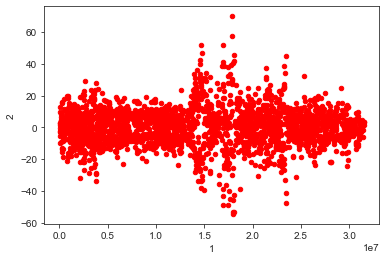

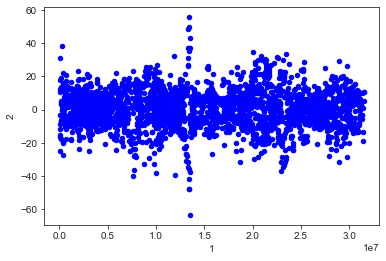

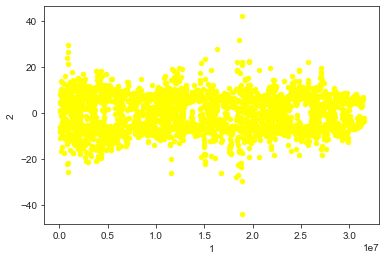

In [149]:
start_df.loc[start_df[0] =="ARH-M1"].plot(kind = 'scatter',x = 1, y=2, color='red')
start_df.loc[start_df[0] =="ARH-M16"].plot(kind = 'scatter',x = 1, y=2, color='blue')
start_df.loc[start_df[0] =="ArL-M24"].plot(kind = 'scatter',x = 1, y=2, color='yellow')
# new.plot(kind = 'scatter',x = 1, y=2, color='red')

In [150]:
start_df.loc[start_df[0] =="ArL-M24"][2]

38     0.75034
38   -8.150255
38    4.668359
38     1.40671
38   -5.938773
        ...   
38    6.201802
38    6.794705
38   -2.232052
38   -3.565017
38   -3.565017
Name: 2, Length: 2670, dtype: object

(12.5, 13.5)

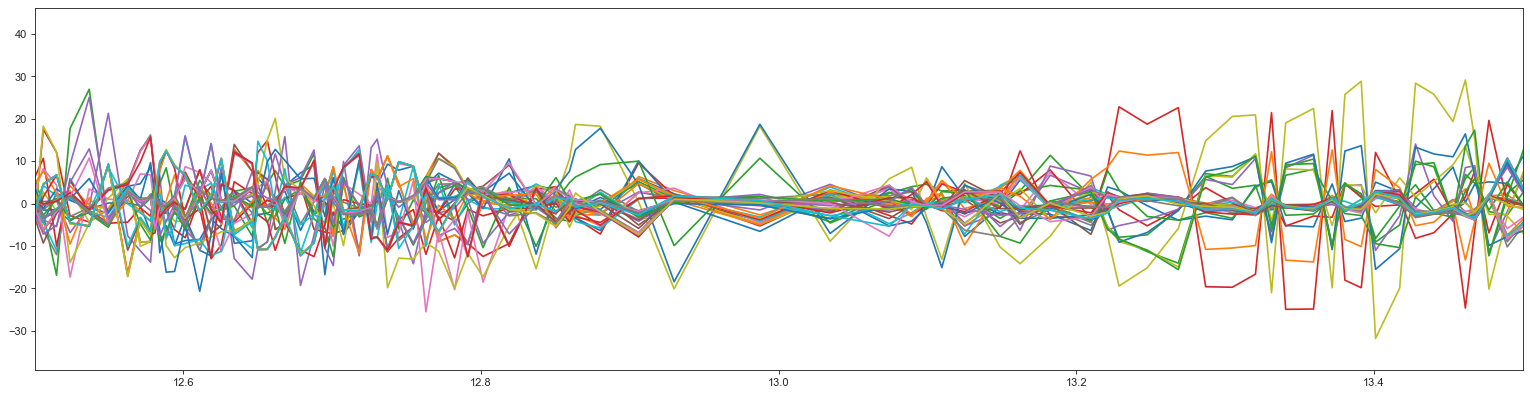

In [157]:
plt.figure(figsize=(24, 6), dpi=80)
for i in samples:
    plt.plot(start_df.loc[start_df[0] == i][1]/1e6, 
         start_df.loc[start_df[0] == i][3])
plt.xlim([12.5,13.5])

In [375]:
model1.components_.shape

(10, 27143)

In [ ]:
# ##############################################################################
# ############# keep this in case you want to do LD pruning later ##############
# ##############################################################################

# def ld_prune(gn, size, step, threshold=.1, n_iter=1):
#     '''
#     LD pruning
#     '''
#     for i in range(n_iter):
#         loc_unlinked = allel.locate_unlinked(gn, size=size, step=step, threshold=threshold)
#         n = np.count_nonzero(loc_unlinked)
#         n_remove = gn.shape[0] - n
#         print('iteration', i+1, 'retaining', n, 'removing', n_remove, 'variants')
#         gn = gn.compress(loc_unlinked, axis=0)
#     return gn

# def plot_ld(gn, title):
#     '''
#     plot LD
#     '''
#     m = allel.rogers_huff_r(gn) ** 2
#     ax = allel.plot_pairwise_ld(m)
#     ax.set_title(title)

In [170]:

def window_GT(callset, window, mode="SNP", start=0, step=None):
    
    '''
    split the genotype into windows based on the num of SNPs or physical chromosome position.
    default start from 0
    '''
    genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
    count= 0
    if mode == "SNP":
        while start < len(genotype) - window:
            start += window 
            count += 1
            gt_subset = genotype[start : start + window]
            yield gt_subset 
        else: 
            gt_subset = genotype[start : ] #final should be 31497110
            yield gt_subset

In [ ]:
def window_GT_BP(callset, window_BP=100, start=0, step=None):
    '''
    split the genotype into windows based on the actual basepairs
    default start from 0 of the chromosome
    step function has implemented yet
    '''
    # list(compress(callset["variants/POS"], flt)) 
    pos = callset["variants/POS"]
    genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
    # split genotype data into chunks
    # return dictionary into {mediate_pos:[pos1, pos2, pos3, pos4...]}
    start = 0
    end = start + 100
    med = (start + end) / 2
    pos_dict = defaultdict(list)
    for i in pos:
        # filter(lambda x: x not in subset_of_A, A)
        if end > i > start:
            pos_dict[med].append(i)
            # print("process 1 " + str(i))
        else:
            while i >= end:
                start += 100
                end  += 100
                med = (start + end) / 2
        pos_dict[med].append(i) if i not in pos_dict[med] else pos_dict[med]
    # temp pos of pos array
    temp_pos = 0 
    for k,v in pos_dict.items():
        temp_pos_start = temp_pos
        temp_pos_end = temp_pos_start + len(v)
        temp_pos = len(v)
        gt_subset_BP = genotype[temp_pos_start : temp_pos_end]
        yield gt_subset_BP 